# 03. Consensus Suspiciousness Ranking

This notebook builds a review-candidate ranking by combining multiple weak signals.

This is safer than relying on a single silver label, because the final goal is human review prioritization rather than automatic punishment or final classification.

## Project Framing

There is no verified ground-truth label for actual viewbot usage. Therefore, this project should not claim to automatically prove viewbot usage.

The practical goal is to reduce the number of broadcasts that a human reviewer must inspect. The model produces suspiciousness scores and review candidates, not final judgments.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.neighbors import LocalOutlierFactor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

pd.set_option('display.max_columns', 120)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

RANDOM_STATE = 42

## 1. Load Data

In [2]:
from pathlib import Path

def find_project_root(start=None):
    """Find the project root from either the root folder or the notebooks folder."""
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / 'csv' / 'session_summary_processed.csv').exists():
            return p
    raise FileNotFoundError('Could not find csv/session_summary_processed.csv. Run this notebook from the project folder.')

PROJECT_ROOT = find_project_root()
CSV_DIR = PROJECT_ROOT / 'csv'
OUTPUT_DIR = PROJECT_ROOT / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

PROJECT_ROOT

WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델')

In [3]:
session = pd.read_csv(CSV_DIR / 'session_summary_processed.csv')
session['silver_suspicious'] = (session['cluster_number'] == 1).astype(int)

feature_cols = [
    'n',
    'viewer_med', 'viewer_max',
    'chat_mean', 'unique_mean',
    'zero_rate', 'zrun_max',
    'gap_med', 'gap_max',
    'log_viewer', 'log_chat', 'log_unique', 'log_zrun',
]

X = session[feature_cols].copy()
y = session['silver_suspicious'].copy()

session.shape, y.mean()

((1954, 22), np.float64(0.05680655066530194))

## 2. Directional Rule Score

Generic anomaly detection can flag both directions of unusual behavior. For example, a session with unusually high chat activity can also be anomalous.

For viewbot-like suspicion, direction matters: viewer activity is high relative to chat response. The rule score captures that direction explicitly.

In [4]:
def pct_rank(s, ascending=True):
    return s.rank(pct=True, ascending=ascending, method='average')

session['rule_zero_rate'] = pct_rank(session['zero_rate'], ascending=True)
session['rule_gap_med'] = pct_rank(session['gap_med'], ascending=True)
session['rule_zrun_max'] = pct_rank(session['zrun_max'], ascending=True)
session['rule_low_chat'] = pct_rank(-session['chat_mean'], ascending=True)
session['rule_low_unique'] = pct_rank(-session['unique_mean'], ascending=True)

rule_cols = ['rule_zero_rate', 'rule_gap_med', 'rule_zrun_max', 'rule_low_chat', 'rule_low_unique']
session['score_rule_directional'] = session[rule_cols].mean(axis=1)

session[['session_key', 'silver_suspicious', 'score_rule_directional', *feature_cols]].sort_values(
    'score_rule_directional', ascending=False
).head(10)

,session_key,silver_suspicious,score_rule_directional,n,viewer_med,viewer_max,chat_mean,unique_mean,zero_rate,zrun_max,gap_med,gap_max,log_viewer,log_chat,log_unique,log_zrun
1174,145_19023370,1,0.9983,119,868.0000,933.0000,0.0672,0.0672,0.9328,32,6.7616,6.8395,6.7673,0.0651,0.0651,3.4965
1057,141_18988637,1,0.9977,119,657.0000,689.0000,0.1345,0.0756,0.9244,50,6.4877,6.5367,6.4892,0.1262,0.0729,3.9318
944,137_18988637,1,0.9974,120,747.0000,806.0000,0.1250,0.1167,0.8917,35,6.6141,6.6933,6.6174,0.1178,0.1103,3.5835
1303,149_19046923,1,0.9967,91,650.0000,720.0000,0.1538,0.1099,0.8901,41,6.4708,6.5806,6.4785,0.1431,0.1043,3.7377
126,44_18387423,1,0.9959,114,"1,162.5000","1,203.0000",0.2544,0.1404,0.8860,23,7.0553,7.0934,7.0592,0.2266,0.1313,3.1781
1201,146_19023370,1,0.9952,119,785.0000,822.0000,0.2269,0.1933,0.8739,22,6.6657,6.7130,6.6670,0.2045,0.1767,3.1355
973,138_18988637,1,0.9948,120,725.0000,830.0000,0.1667,0.1583,0.8750,19,6.5793,6.7226,6.5876,0.1542,0.1470,2.9957
86,40_18386889,1,0.9946,119,498.0000,602.0000,0.1513,0.1513,0.8655,27,6.1985,6.3969,6.2126,0.1409,0.1409,3.3322
1028,140_18988637,1,0.9943,118,649.0000,719.0000,0.4068,0.2458,0.8559,32,6.4661,6.5793,6.4770,0.3413,0.2197,3.4965
116,43_18386889,1,0.9930,120,501.0000,518.0000,0.3917,0.2000,0.8250,20,6.2166,6.2519,6.2186,0.3305,0.1823,3.0445


## 3. Supervised Silver-label Score with Out-of-fold Prediction

The supervised models learn the silver label, but the score for each row is generated out-of-fold.

This prevents each session from being scored by a model that was trained on that same row.

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logistic_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('model', LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE)),
])

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestClassifier(
        n_estimators=500,
        max_depth=5,
        min_samples_leaf=5,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

session['score_logistic_oof'] = cross_val_predict(
    logistic_pipe, X, y, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

session['score_rf_oof'] = cross_val_predict(
    rf_pipe, X, y, cv=cv, method='predict_proba', n_jobs=-1
)[:, 1]

pd.DataFrame({
    'score': ['logistic_oof', 'rf_oof', 'rule_directional'],
    'pr_auc_vs_silver': [
        average_precision_score(y, session['score_logistic_oof']),
        average_precision_score(y, session['score_rf_oof']),
        average_precision_score(y, session['score_rule_directional']),
    ],
    'roc_auc_vs_silver': [
        roc_auc_score(y, session['score_logistic_oof']),
        roc_auc_score(y, session['score_rf_oof']),
        roc_auc_score(y, session['score_rule_directional']),
    ],
})

,score,pr_auc_vs_silver,roc_auc_vs_silver
0,logistic_oof,0.9977,0.9998
1,rf_oof,0.9995,1.0000
2,rule_directional,0.9272,0.9918


## 4. Unsupervised Anomaly Score

Isolation Forest and LOF are used as generic anomaly detectors.

These scores are useful as supporting signals, but they are not directional by themselves. They should be interpreted together with the directional rule score.

In [6]:
preprocess = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
])
X_scaled = preprocess.fit_transform(X)

contamination = float(y.mean())

iforest = IsolationForest(
    n_estimators=500,
    contamination=contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iforest.fit(X_scaled)
# IsolationForest decision_function is larger for more normal points, so we flip the sign.
session['score_iforest_raw'] = -iforest.decision_function(X_scaled)

lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=contamination,
    novelty=False,
)
lof_label = lof.fit_predict(X_scaled)
# LOF negative_outlier_factor_ is smaller for stronger outliers, so we flip the sign.
session['score_lof_raw'] = -lof.negative_outlier_factor_

session[['score_iforest_raw', 'score_lof_raw']].describe()

,score_iforest_raw,score_lof_raw
count,"1,954.0000","1,954.0000"
mean,-0.1293,1.1557
std,0.0657,0.3219
min,-0.1967,0.9528
25%,-0.1748,1.0078
50%,-0.1493,1.0584
75%,-0.1091,1.1737
max,0.1997,7.7463


## 5. Percentile Normalization and Consensus Score

Different models produce scores on different scales. We convert each score to a percentile rank and average them.

The consensus score is a review priority score, not a calibrated probability.

In [7]:
score_cols = [
    'score_rule_directional',
    'score_logistic_oof',
    'score_rf_oof',
    'score_iforest_raw',
    'score_lof_raw',
]

for col in score_cols:
    session[col + '_pct'] = pct_rank(session[col], ascending=True)

consensus_cols = [col + '_pct' for col in score_cols]
session['score_consensus'] = session[consensus_cols].mean(axis=1)

session[consensus_cols + ['score_consensus']].describe()

,score_rule_directional_pct,score_logistic_oof_pct,score_rf_oof_pct,score_iforest_raw_pct,score_lof_raw_pct,score_consensus
count,"1,954.0000","1,954.0000","1,954.0000","1,954.0000","1,954.0000","1,954.0000"
mean,0.5003,0.5003,0.5003,0.5003,0.5003,0.5003
std,0.2887,0.2887,0.2340,0.2887,0.2887,0.1864
min,0.0005,0.0005,0.3503,0.0005,0.0005,0.1573
25%,0.2504,0.2504,0.3503,0.2504,0.2504,0.3611
50%,0.5003,0.5003,0.3503,0.5003,0.5003,0.4620
75%,0.7501,0.7501,0.7449,0.7501,0.7501,0.5997
max,1.0000,0.9918,1.0000,1.0000,1.0000,0.9947


## 6. Top-k Overlap and Model Agreement

In [8]:
def topk_set(df, score_col, k):
    return set(df.nlargest(k, score_col)['session_key'])

positive_total = int(y.sum())
ks = [20, 50, 100, positive_total, 200]
rank_rows = []

for score_col in ['score_rule_directional', 'score_logistic_oof', 'score_rf_oof', 'score_iforest_raw', 'score_lof_raw', 'score_consensus']:
    for k in ks:
        top = session.nlargest(k, score_col)
        rank_rows.append({
            'score': score_col,
            'top_k': k,
            'silver_positive_in_top_k': int(top['silver_suspicious'].sum()),
            'precision_vs_silver': top['silver_suspicious'].mean(),
            'recall_vs_silver': top['silver_suspicious'].sum() / positive_total,
        })

rank_table = pd.DataFrame(rank_rows)
rank_table.pivot(index='top_k', columns='score', values='precision_vs_silver')

score,score_consensus,score_iforest_raw,score_lof_raw,score_logistic_oof,score_rf_oof,score_rule_directional
top_k,,,,,,
20,1.0000,0.1500,0.2000,1.0000,1.0000,1.0000
50,0.9600,0.3400,0.2000,1.0000,1.0000,1.0000
100,0.7200,0.3900,0.1600,1.0000,1.0000,0.8800
111,0.6847,0.3964,0.1532,0.9820,0.9910,0.8378
200,0.5550,0.3750,0.1350,0.5550,0.5550,0.5400


In [9]:
agreement_rows = []
base_k = positive_total
score_for_agreement = ['score_rule_directional', 'score_logistic_oof', 'score_rf_oof', 'score_iforest_raw', 'score_lof_raw', 'score_consensus']

for a in score_for_agreement:
    set_a = topk_set(session, a, base_k)
    for b in score_for_agreement:
        set_b = topk_set(session, b, base_k)
        agreement_rows.append({
            'score_a': a,
            'score_b': b,
            'jaccard_at_pos_k': len(set_a & set_b) / len(set_a | set_b),
        })

agreement = pd.DataFrame(agreement_rows).pivot(index='score_a', columns='score_b', values='jaccard_at_pos_k')
agreement

score_b,score_consensus,score_iforest_raw,score_lof_raw,score_logistic_oof,score_rf_oof,score_rule_directional
score_a,,,,,,
score_consensus,1.0000,0.2832,0.1503,0.5102,0.5102,0.5205
score_iforest_raw,0.2832,1.0000,0.2759,0.2472,0.2472,0.2333
score_lof_raw,0.1503,0.2759,1.0000,0.0829,0.0829,0.0673
score_logistic_oof,0.5102,0.2472,0.0829,1.0000,0.9646,0.7077
score_rf_oof,0.5102,0.2472,0.0829,0.9646,1.0000,0.7077
score_rule_directional,0.5205,0.2333,0.0673,0.7077,0.7077,1.0000


## 7. Review Candidate Groups

The review groups are defined as:

- `high_confidence_review`: silver label and consensus score both indicate suspicion
- `directional_review`: directional mismatch is strong even if KMeans did not flag the session
- `anomaly_only_review`: anomaly detectors flag the session, but directional mismatch is weaker

This separation helps avoid calling every anomaly viewbot-like.

In [10]:
q90 = session['score_consensus'].quantile(0.90)
q95 = session['score_consensus'].quantile(0.95)
rule_q90 = session['score_rule_directional'].quantile(0.90)
anom_q90 = session[['score_iforest_raw_pct', 'score_lof_raw_pct']].mean(axis=1).quantile(0.90)

session['review_group'] = 'low_priority'
session.loc[
    (session['silver_suspicious'].eq(1)) &
    (session['score_consensus'].ge(q90)),
    'review_group'
] = 'high_confidence_review'

session.loc[
    (session['review_group'].eq('low_priority')) &
    (session['score_consensus'].ge(q95)) &
    (session['score_rule_directional'].ge(rule_q90)),
    'review_group'
] = 'directional_review'

session.loc[
    (session['review_group'].eq('low_priority')) &
    (session[['score_iforest_raw_pct', 'score_lof_raw_pct']].mean(axis=1).ge(anom_q90)) &
    (session['score_rule_directional'].lt(rule_q90)),
    'review_group'
] = 'anomaly_only_review'

session['review_group'].value_counts()

review_group
low_priority              1690
anomaly_only_review        136
high_confidence_review     110
directional_review          18
Name: count, dtype: int64

In [11]:
review_cols = [
    'session_key', 'run_id', 'broad_no', 'user_id', 'category_id',
    'review_group', 'cluster_number', 'silver_suspicious',
    'score_consensus', 'score_rule_directional', 'score_logistic_oof', 'score_rf_oof',
    'score_iforest_raw_pct', 'score_lof_raw_pct',
    'n', 'start', 'end', 'viewer_med', 'viewer_max', 'chat_mean', 'unique_mean',
    'zero_rate', 'zrun_max', 'gap_med', 'gap_max',
]

review_candidates = session.sort_values('score_consensus', ascending=False)[review_cols]
review_candidates.head(30)

,session_key,run_id,broad_no,user_id,category_id,review_group,cluster_number,silver_suspicious,score_consensus,score_rule_directional,score_logistic_oof,score_rf_oof,score_iforest_raw_pct,score_lof_raw_pct,n,start,end,viewer_med,viewer_max,chat_mean,unique_mean,zero_rate,zrun_max,gap_med,gap_max
1057,141_18988637,141,18988637,2ff900f58d92d9ba080dc5cd95705c1b,DNF 듀얼,high_confidence_review,1,1,0.9947,0.9977,1.0000,0.9999,0.9903,0.9939,119,2026-05-21 15:00:00,2026-05-21 16:59:00,657.0000,689.0000,0.1345,0.0756,0.9244,50,6.4877,6.5367
59,37_18386839,37,18386839,123cf2a78842d677e66ec57f3e3039c2,던전앤파이터,high_confidence_review,1,1,0.9922,0.9873,1.0000,0.9999,0.9872,0.9908,116,2026-04-16 17:00:00,2026-04-16 19:00:00,131.5000,150.0000,0.0517,0.0259,0.9741,41,4.8862,5.0173
1303,149_19046923,149,19046923,d563bf0bbf825540ba5292e837d41a2f,농구,high_confidence_review,1,1,0.9917,0.9967,1.0000,0.9997,0.9913,0.9893,91,2026-05-23 15:00:00,2026-05-23 16:30:00,650.0000,720.0000,0.1538,0.1099,0.8901,41,6.4708,6.5806
944,137_18988637,137,18988637,2ff900f58d92d9ba080dc5cd95705c1b,프라시아 전기,high_confidence_review,1,1,0.9903,0.9974,1.0000,0.9998,0.9862,0.9846,120,2026-05-20 15:00:00,2026-05-20 16:59:00,747.0000,806.0000,0.1250,0.1167,0.8917,35,6.6141,6.6933
1028,140_18988637,140,18988637,2ff900f58d92d9ba080dc5cd95705c1b,서든어택,high_confidence_review,1,1,0.9870,0.9943,1.0000,0.9998,0.9836,0.9754,118,2026-05-20 23:00:00,2026-05-21 00:59:00,649.0000,719.0000,0.4068,0.2458,0.8559,32,6.4661,6.5793
1174,145_19023370,145,19023370,2ff900f58d92d9ba080dc5cd95705c1b,카운터-스트라이크 온라인,high_confidence_review,1,1,0.9863,0.9983,1.0000,0.9980,0.9887,0.9800,119,2026-05-22 15:00:00,2026-05-22 16:59:00,868.0000,933.0000,0.0672,0.0672,0.9328,32,6.7616,6.8395
86,40_18386889,40,18386889,df434464f7e4802bee47c4b9c88331f7,던전앤파이터,high_confidence_review,1,1,0.9833,0.9946,1.0000,0.9998,0.9806,0.9585,119,2026-04-17 17:00:00,2026-04-17 18:59:00,498.0000,602.0000,0.1513,0.1513,0.8655,27,6.1985,6.3969
1749,165_19109380,165,19109380,e5a5b5bc614e3b256052c83ebcfb70fd,블루 아카이브,high_confidence_review,1,1,0.9819,0.9664,1.0000,0.9982,0.9882,0.9795,115,2026-05-27 15:00:00,2026-05-27 16:59:00,72.0000,92.0000,0.0174,0.0174,0.9826,31,4.2767,4.5326
1638,161_19097929,161,19097929,2a6772fe35f1508f27676a5422d1a136,디아블로 II: 레저렉션,high_confidence_review,1,1,0.9807,0.9690,1.0000,0.9998,0.9780,0.9596,118,2026-05-26 15:00:00,2026-05-26 17:01:00,93.0000,109.0000,0.4237,0.3644,0.7119,28,4.4248,4.7005
126,44_18387423,44,18387423,4f0e2fbfad9960eee61770e144b820b3,던전앤파이터,high_confidence_review,1,1,0.9791,0.9959,1.0000,0.9992,0.9867,0.9411,114,2026-04-18 20:00:00,2026-04-18 21:59:00,"1,162.5000","1,203.0000",0.2544,0.1404,0.8860,23,7.0553,7.0934


## 8. Visualization

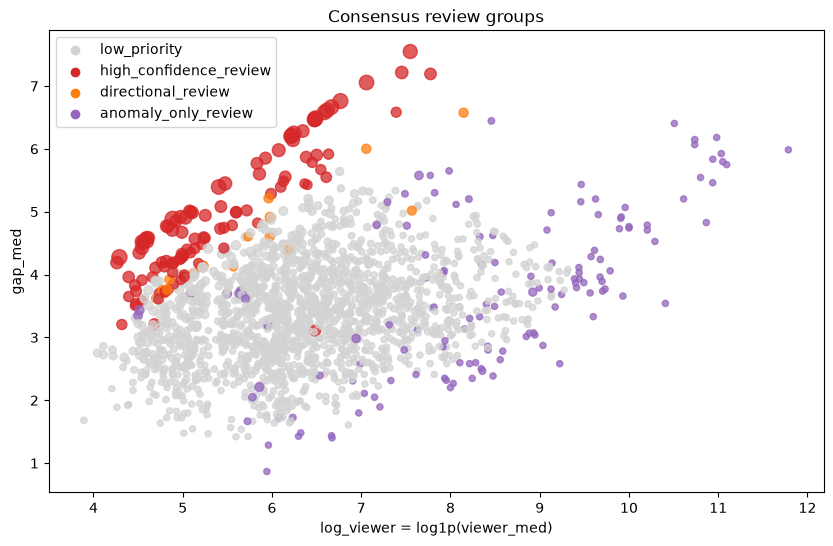

In [12]:
color_map = {
    'low_priority': 'lightgray',
    'high_confidence_review': 'tab:red',
    'directional_review': 'tab:orange',
    'anomaly_only_review': 'tab:purple',
}
colors = session['review_group'].map(color_map)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    session['log_viewer'],
    session['gap_med'],
    c=colors,
    s=20 + 100 * session['zero_rate'],
    alpha=0.75,
)
ax.set_xlabel('log_viewer = log1p(viewer_med)')
ax.set_ylabel('gap_med')
ax.set_title('Consensus review groups')

for group, color in color_map.items():
    ax.scatter([], [], c=color, label=group)
ax.legend(loc='best')
plt.show()

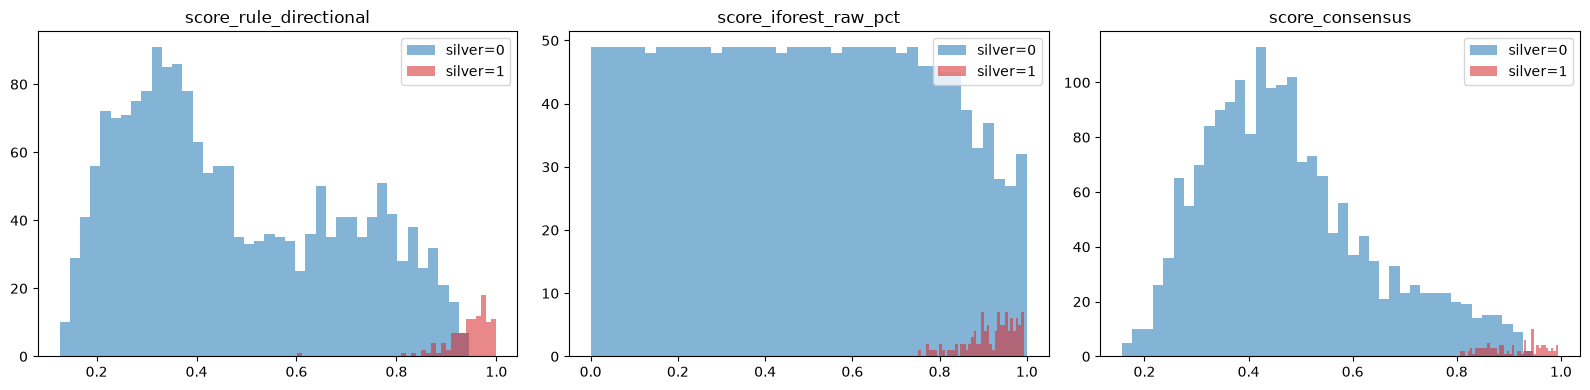

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['score_rule_directional', 'score_iforest_raw_pct', 'score_consensus']):
    for label, color in [(0, 'tab:blue'), (1, 'tab:red')]:
        values = session.loc[session['silver_suspicious'] == label, col]
        ax.hist(values, bins=40, alpha=0.55, color=color, label=f'silver={label}')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

## 9. Save Results

The main output is `outputs/03_review_candidates.csv`, which can be used for case studies in the final presentation.

In [14]:
review_path = OUTPUT_DIR / '03_review_candidates.csv'
rank_path = OUTPUT_DIR / '03_topk_overlap_table.csv'
agreement_path = OUTPUT_DIR / '03_score_agreement_table.csv'

review_candidates.to_csv(review_path, index=False, encoding='utf-8-sig')
rank_table.to_csv(rank_path, index=False, encoding='utf-8-sig')
agreement.to_csv(agreement_path, encoding='utf-8-sig')

review_path, rank_path, agreement_path

(WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델/outputs/03_review_candidates.csv'),
 WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델/outputs/03_topk_overlap_table.csv'),
 WindowsPath('c:/Users/82103/OneDrive/바탕 화면/SNU_2026-1/데이터마이닝/플젝/최종모델/outputs/03_score_agreement_table.csv'))